# <a id="#">Task 4 – Edge detection: Derivative operators</a>

In [8]:
import numpy
import matplotlib.pyplot as plt
import skimage.io

---

## Prewitt filters

**<a id="#">Task 4.1.1.</a>** Load the image `data/astronaut.png` and show it:

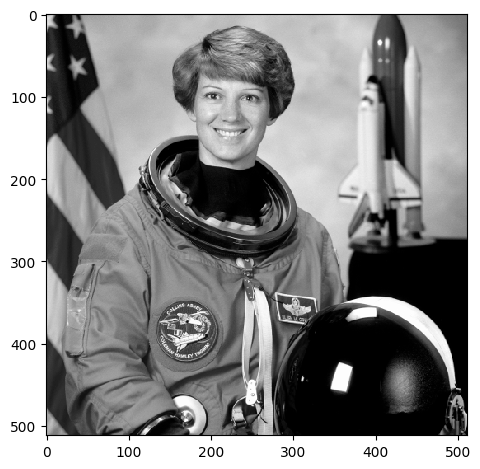

In [9]:
img = skimage.io.imread('data/astronaut.png')
skimage.io.imshow(img)

**<a id="#">Task 4.1.2.</a>** Implement horizontal and vertical 3&times;3 Prewitt filters:

In [10]:
def prewitt_h(img_in):
    result = numpy.zeros(img_in.shape)
    n = 1
    for p in numpy.ndindex(img_in.shape):
        neighborhood_sum = 0

        if (p[0] - n < 0 or p[0] + n >= img_in.shape[0] or
            p[1] - n < 0 or p[1] + n >= img_in.shape[1]):
            continue

        for q in numpy.ndindex(3, 3): 
            i = p[0] + q[0] - n
            j = p[1] + q[1] - n

            if q[1] == 0:
                a = img_in[i, j] * (-1)
            elif q[1] == 1:
                a = 0
            else:
                a = img_in[i, j]

            neighborhood_sum += a

        result[p] = neighborhood_sum / (6*255) #Die 255 habe ich hinzugefügt, da das Vergleichsbild vermutlich normiert worden ist. Umd die Bilder also richtig vergleichen zu können, muss ich hier entsprechend normieren.
    return result
    
def prewitt_v(img_in):
    result = numpy.zeros(img_in.shape)
    n = 1
    for p in numpy.ndindex(img_in.shape):
        neighborhood_sum = 0

        if (p[0] - n < 0 or p[0] + n >= img_in.shape[0] or
            p[1] - n < 0 or p[1] + n >= img_in.shape[1]):
            continue

        for q in numpy.ndindex(3, 3): 
            i = p[0] + q[0] - n
            j = p[1] + q[1] - n

            if q[0] == 0:
                b = img_in[i, j] * (-1)
            elif q[0] == 1:
                b = 0
            else:
                b = img_in[i, j] * (+1)

            neighborhood_sum += b

        result[p] = neighborhood_sum / (6*255)
    return result

**<a id="#">Task 4.1.3.</a>** Test your above solution using the functions `prewitt_h` and `prewitt_v` for the previously loaded image and show the result:

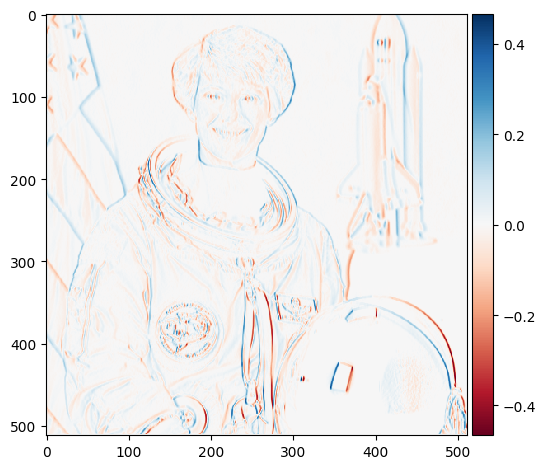

In [11]:
x = prewitt_h(img)
skimage.io.imshow(x)


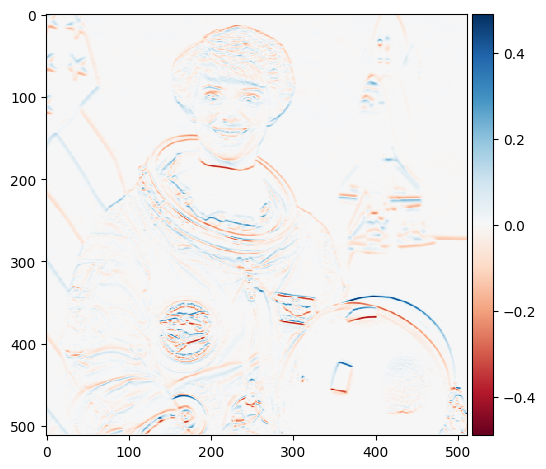

In [12]:
y = prewitt_v(img)
skimage.io.imshow(y)


**<a id="#">Task 4.1.4.</a>** Compare your results with the correct result image `data/astronaut_prewitt_h.tiff` and `data/astronaut_prewitt_v.tiff`:

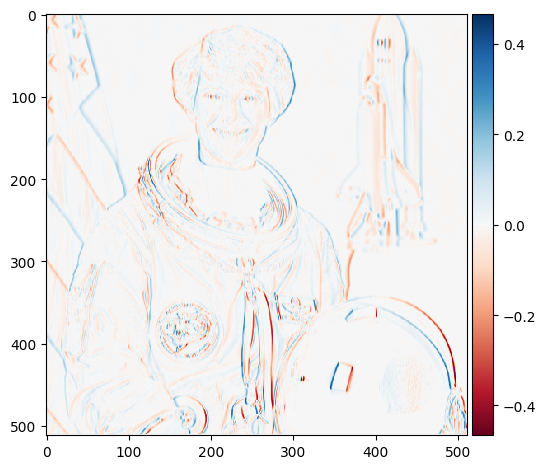

In [13]:
img2 = skimage.io.imread("data/astronaut_prewitt_h.tiff") #Die Bilder sahen ziemlich anders aus (also mein erzeugtes und das Vergleichsbild), weil ich mein img mit plt. geladen hatte, aber das Vergleichsbild mit skimage.io. geladen hatte. Ich habe jetzt alles mit skimage.io. und komme auf das richtige ergebnis.
skimage.io.imshow(img2)
assert numpy.allclose(x, img2, atol=1/255) #Der vergleich funktioniert nicht. Die Skala beim Vergleichsbild -0.4 bis 0.4. Bei meinem Bild -100 bis 100. Korrigiert durch Normierungsfaktor 255.

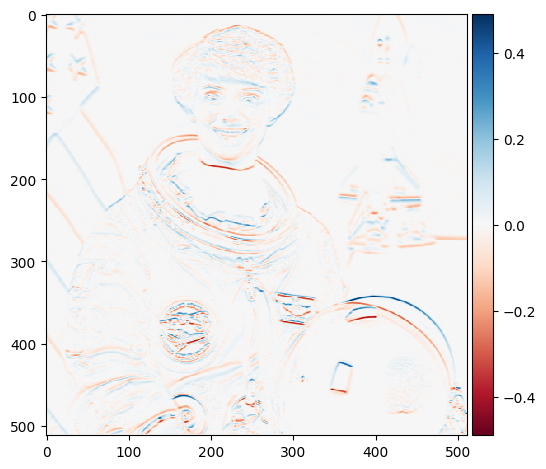

In [15]:
img3 = skimage.io.imread("data/astronaut_prewitt_v.tiff")
skimage.io.imshow(img3)
assert numpy.allclose(y, img3, atol=1/255) # ich habe die koeffizienten +1 und -1 im code vertauscht, jetzt klappt der Vergleich.

---

## Edge detection

**<a id="#">Task 4.2.1.</a>** Use your results from **Task 4.1.2 – 4.1.3** to compute the *gradient magnitude* of the image:

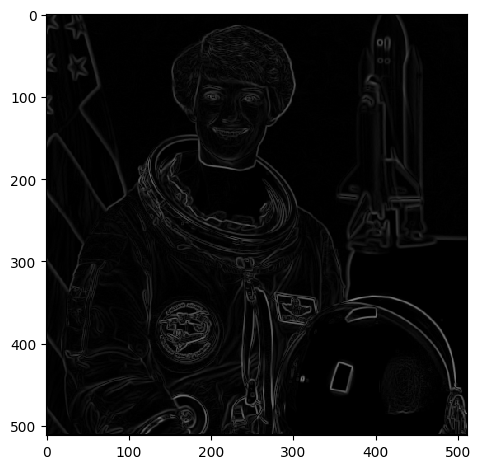

In [19]:
maggrad_img = numpy.sqrt(pow(x, 2) + pow(y, 2))
skimage.io.imshow(maggrad_img)

**<a id="#">Task 4.2.2.</a>** Compare your result with the correct result image `data/astronaut_prewitt_gradmag.tiff`:

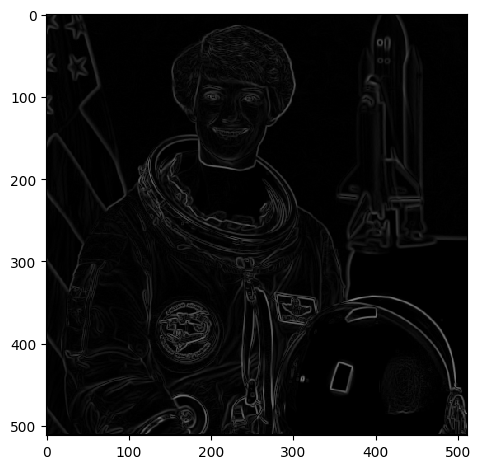

In [20]:
img4 = skimage.io.imread('data/astronaut_prewitt_gradmag.tiff')
skimage.io.imshow(img4)
assert numpy.allclose(maggrad_img, img4, atol=1/255)

---

## Sobel filters (bonus)

**<a id="#">Task 4.3.1.</a>** Implement the two functions `sobel_h` and `sobel_v` for horizontal and vertical 3&times;3 Sobel filtering, respectively:

**<a id="#">Task 4.3.2.</a>** Test your above solution using the functions `sobel_h` and `sobel_v` for the previously loaded image and show the result:

**<a id="#">Task 4.3.3.</a>** Compare your results with the correct result image `data/astronaut_sobel_h.tiff` and `data/astronaut_sobel_v.tiff`: